In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.ensemble import IsolationForest
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully! ✅")

All libraries imported successfully! ✅


In [2]:
# Cell 2 — Fetch Stock Data
ticker = "AAPL"  # Apple Stock (we can change this later)
df = yf.download(ticker, start="2020-01-01", end="2024-12-31")

print(f"Data Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Data Shape: (1257, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


In [3]:
# Cell 3 — Check & Clean Data
print("Column Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Column Names: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Data Types:
 Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

Missing Values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Basic Statistics:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,151.300258,152.820988,149.602776,151.144223,9.061168e+07
std,41.778189,41.916451,41.553582,41.717783,5.324605e+07
min,54.163696,55.160694,51.324793,55.059305,2.323470e+07
25%,126.249863,127.334371,124.234793,125.724367,5.546960e+07
50%,149.942215,151.690648,147.948354,149.768072,7.629970e+07
75%,175.746521,177.444987,174.316223,175.593375,1.077601e+08
max,257.375610,258.448771,255.994450,256.550893,4.265100e+08


In [4]:
# Cell 4 — Flatten Column Names
df.columns = df.columns.get_level_values(0)
df = df.reset_index()

print("Cleaned Column Names:", df.columns.tolist())
df.head()

Cleaned Column Names: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


Price,Date,Close,High,Low,Open,Volume
0,2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
1,2020-01-03,71.630653,72.389273,71.406681,71.563221,146322800
2,2020-01-06,72.201401,72.239935,70.503539,70.754006,118387200
3,2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
4,2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


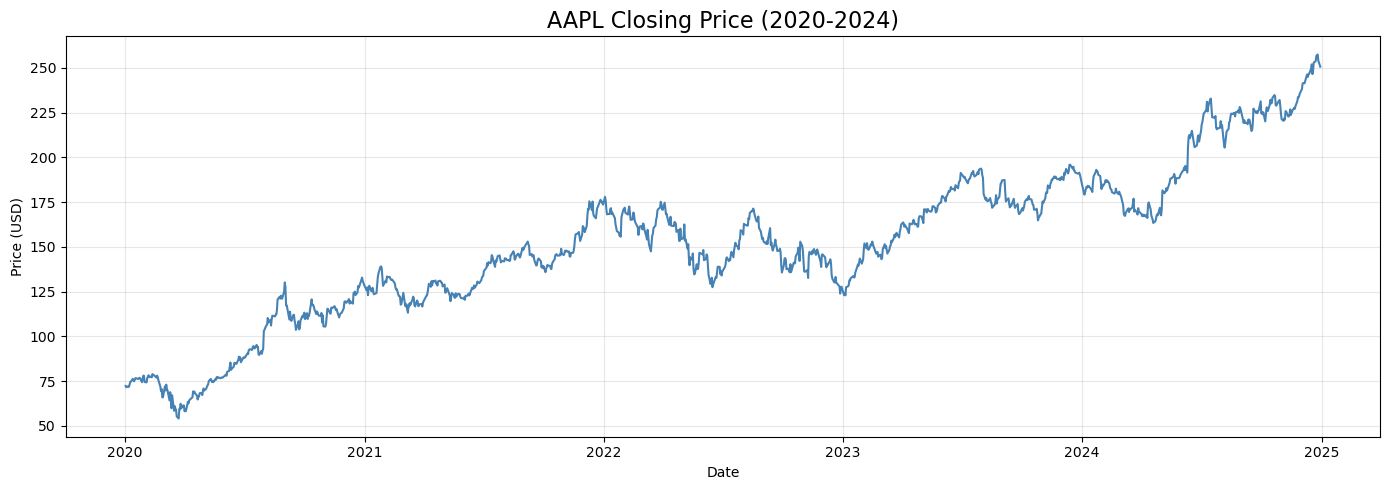

Chart saved! ✅


In [5]:
# Cell 5 — Plot Closing Price
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], color='steelblue', linewidth=1.5)
plt.title('AAPL Closing Price (2020-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('closing_price.png', dpi=150)
plt.show()
print("Chart saved! ✅")

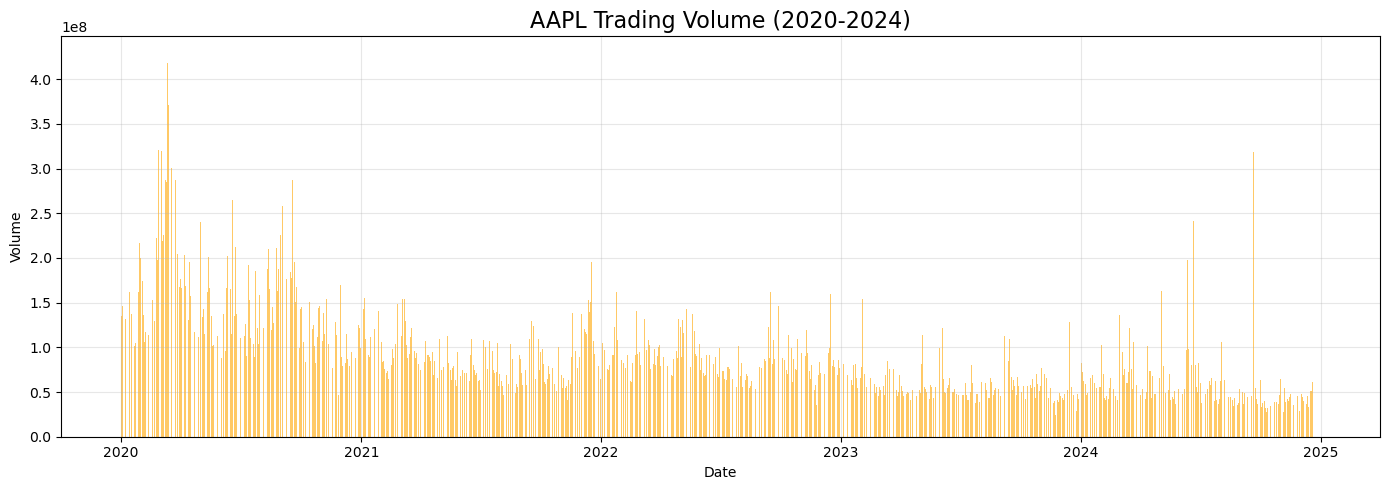

Chart saved! ✅


In [6]:
# Cell 6 — Plot Volume
plt.figure(figsize=(14, 5))
plt.bar(df['Date'], df['Volume'], color='orange', alpha=0.6)
plt.title('AAPL Trading Volume (2020-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('volume.png', dpi=150)
plt.show()
print("Chart saved! ✅")

In [7]:
# Cell 7 — Anomaly Detection using Isolation Forest
# Prepare features
features = df[['Close', 'Volume']].copy()

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(features)

# -1 = Anomaly, 1 = Normal
anomalies = df[df['Anomaly'] == -1]

print(f"Total Anomalies Detected: {len(anomalies)}")
print(f"\nFirst 5 Anomalies:")
anomalies[['Date', 'Close', 'Volume']].head()

Total Anomalies Detected: 63

First 5 Anomalies:


Price,Date,Close,Volume
18,2020-01-29,78.111427,216229200
35,2020-02-24,71.981689,222195200
36,2020-02-25,69.543503,230673600
38,2020-02-27,66.028671,320605600
39,2020-02-28,65.990059,426510000


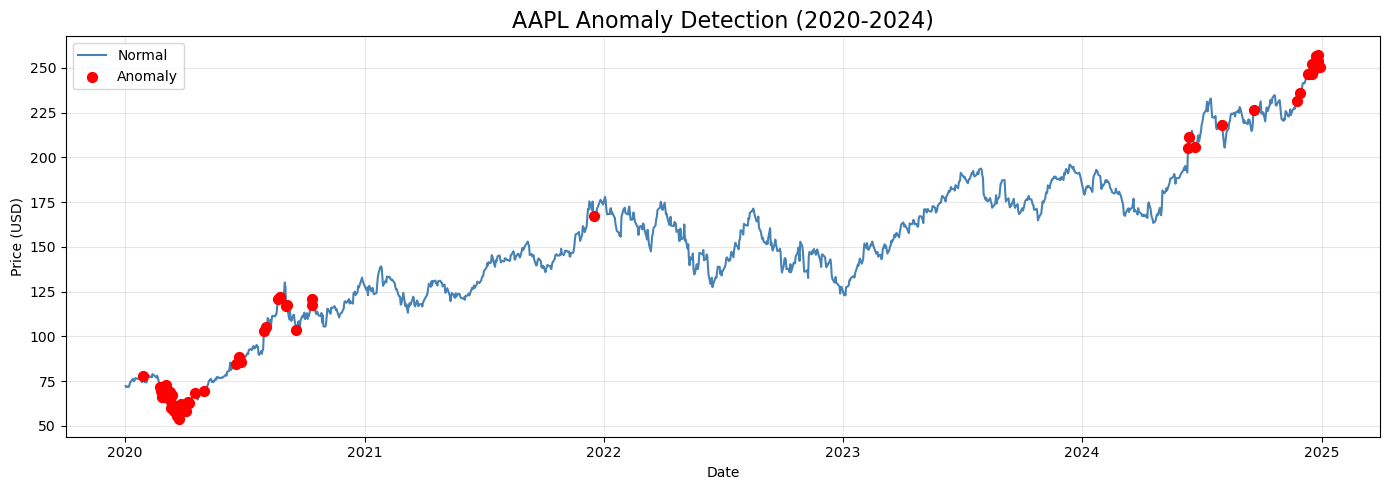

Chart saved! ✅


In [8]:
# Cell 8 — Visualize Anomalies
plt.figure(figsize=(14, 5))

# Normal points
plt.plot(df['Date'], df['Close'], 
         color='steelblue', linewidth=1.5, label='Normal')

# Anomaly points
plt.scatter(anomalies['Date'], anomalies['Close'], 
            color='red', s=50, zorder=5, label='Anomaly')

plt.title('AAPL Anomaly Detection (2020-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_detection.png', dpi=150)
plt.show()
print("Chart saved! ✅")

In [9]:
# Cell 9 — Prepare Data for ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Use closing price for forecasting
close_prices = df['Close'].values

# Use last 100 days for training
train_data = close_prices[-100:]

print(f"Training on last 100 days of data")
print(f"Last 5 closing prices: {train_data[-5:]}")

Training on last 100 days of data
Last 5 closing prices: [253.64941406 256.56082153 257.37561035 253.96739197 250.59889221]


In [10]:
# Cell 10 — Build & Fit ARIMA Model
# ARIMA(p,d,q) — p=5, d=1, q=0 is good for stock data
model = ARIMA(train_data, order=(5, 1, 0))
fitted_model = model.fit()

print("ARIMA Model trained successfully! ✅")
print(f"\nModel Summary:")
print(fitted_model.summary())

ARIMA Model trained successfully! ✅

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -233.761
Date:                Sat, 13 Jun 2026   AIC                            479.523
Time:                        22:51:51   BIC                            495.093
Sample:                             0   HQIC                           485.823
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0700      0.110      0.638      0.523      -0.145       0.285
ar.L2         -0.1057      0.109     -0.967      0.334      -0.320       0.109


In [11]:
# Cell 11 — Forecast Next 7 Days
forecast = fitted_model.forecast(steps=7)

# Create forecast dates
last_date = df['Date'].iloc[-1]
forecast_dates = pd.date_range(start=last_date, periods=8, freq='B')[1:]

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'Forecasted_Price': forecast
})

print("7-Day Price Forecast for AAPL:")
print(forecast_df.to_string(index=False))

7-Day Price Forecast for AAPL:
      Date  Forecasted_Price
2024-12-31        251.078175
2025-01-01        251.838304
2025-01-02        251.610443
2025-01-03        251.100389
2025-01-06        251.314376
2025-01-07        251.512251
2025-01-08        251.474449


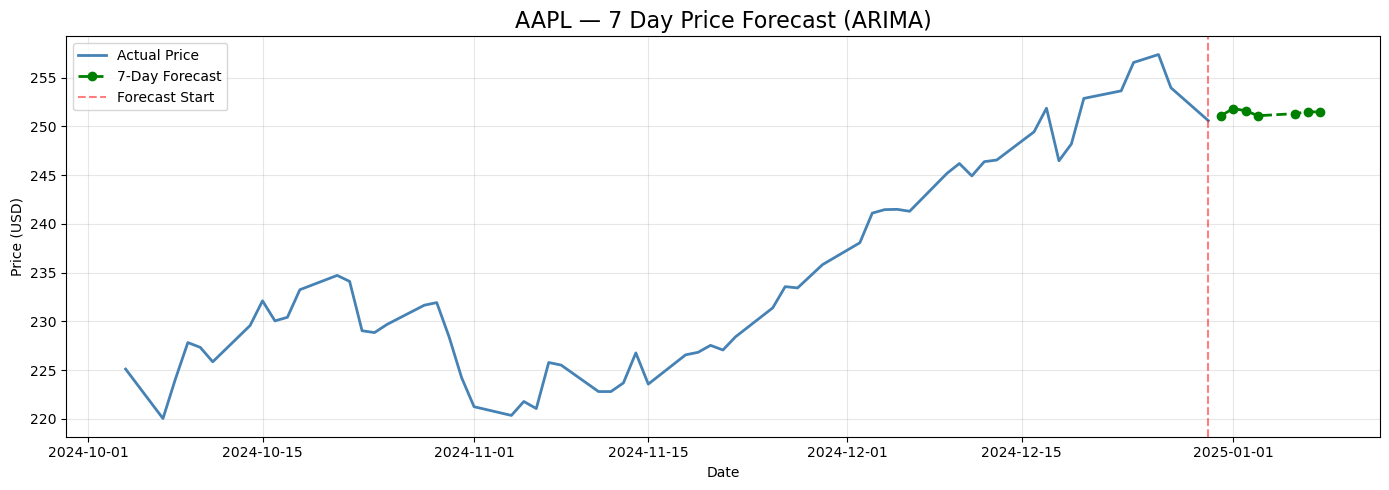

Forecast chart saved! ✅


In [12]:
# Cell 12 — Visualize Forecast
plt.figure(figsize=(14, 5))

# Plot last 60 days of actual data
plt.plot(df['Date'].iloc[-60:], df['Close'].iloc[-60:],
         color='steelblue', linewidth=2, label='Actual Price')

# Plot forecast
plt.plot(forecast_df['Date'], forecast_df['Forecasted_Price'],
         color='green', linewidth=2, linestyle='--',
         marker='o', markersize=6, label='7-Day Forecast')

# Add vertical line separating actual vs forecast
plt.axvline(x=df['Date'].iloc[-1], color='red', 
            linestyle='--', alpha=0.5, label='Forecast Start')

plt.title('AAPL — 7 Day Price Forecast (ARIMA)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast.png', dpi=150)
plt.show()
print("Forecast chart saved! ✅")

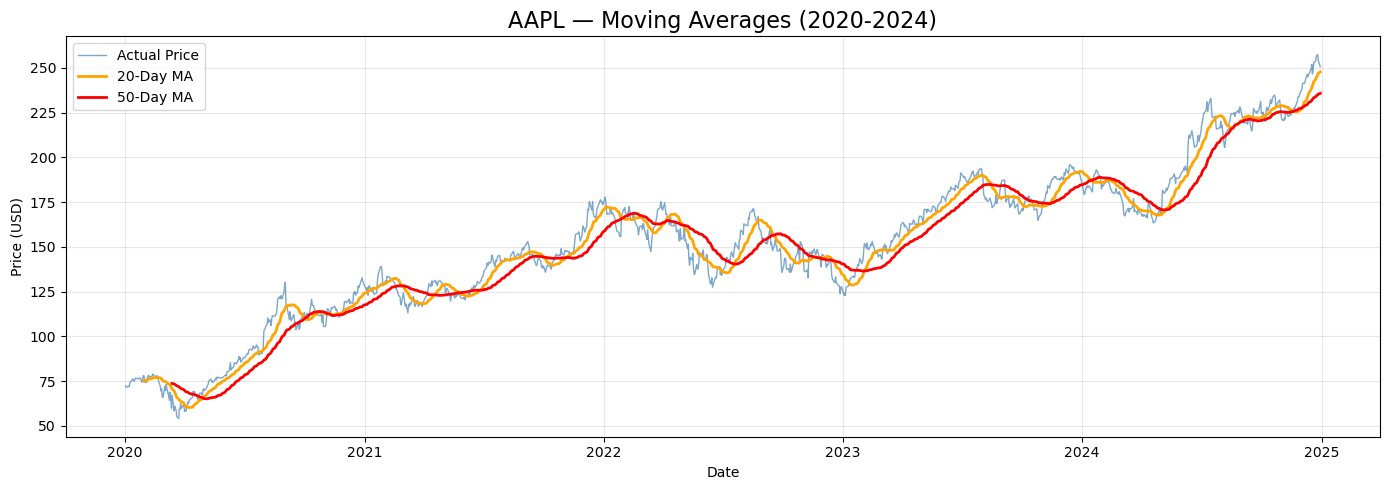

Moving averages chart saved! ✅


In [13]:
# Cell 13 — Moving Averages
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], 
         color='steelblue', linewidth=1, label='Actual Price', alpha=0.7)
plt.plot(df['Date'], df['MA20'], 
         color='orange', linewidth=2, label='20-Day MA')
plt.plot(df['Date'], df['MA50'], 
         color='red', linewidth=2, label='50-Day MA')

plt.title('AAPL — Moving Averages (2020-2024)', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('moving_averages.png', dpi=150)
plt.show()
print("Moving averages chart saved! ✅")

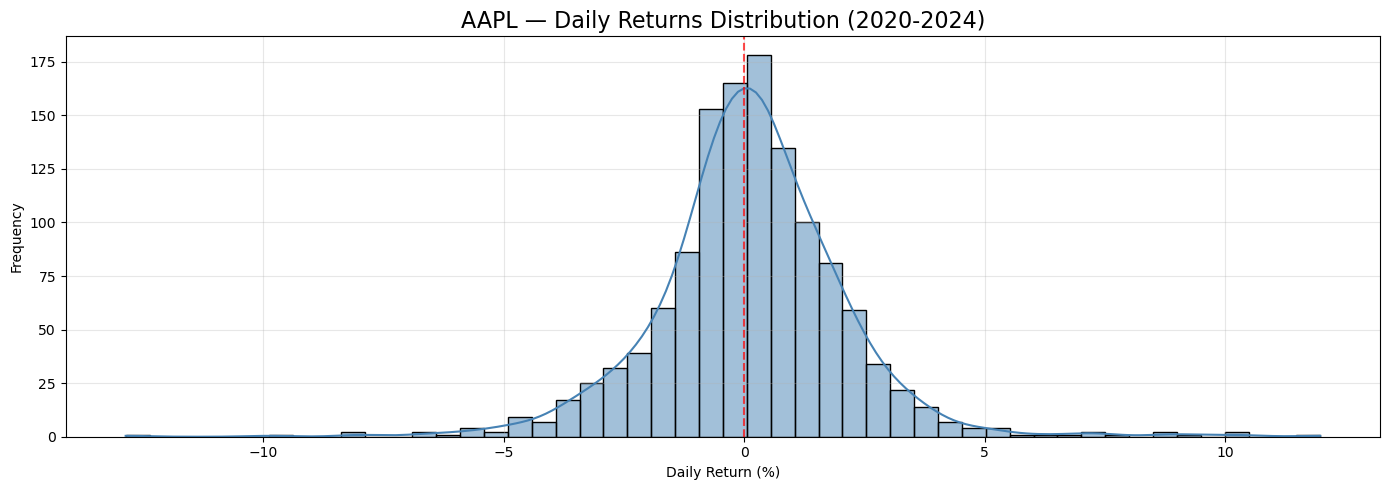

Average Daily Return: 0.12%
Max Single Day Gain: 11.98%
Max Single Day Loss: -12.86%
Chart saved! ✅


In [14]:
# Cell 14 — Daily Returns Distribution
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(14, 5))
sns.histplot(df['Daily_Return'].dropna(), bins=50, 
             color='steelblue', kde=True)

plt.axvline(x=0, color='red', linestyle='--', alpha=0.7)
plt.title('AAPL — Daily Returns Distribution (2020-2024)', fontsize=16)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('daily_returns.png', dpi=150)
plt.show()

print(f"Average Daily Return: {df['Daily_Return'].mean():.2f}%")
print(f"Max Single Day Gain: {df['Daily_Return'].max():.2f}%")
print(f"Max Single Day Loss: {df['Daily_Return'].min():.2f}%")
print("Chart saved! ✅")

In [15]:
# Cell 15 — Final Summary Table
summary = {
    'Metric': [
        'Total Trading Days',
        'Start Price (Jan 2020)',
        'End Price (Dec 2024)',
        'Total Return',
        'Average Daily Return',
        'Max Single Day Gain',
        'Max Single Day Loss',
        'Total Anomalies Detected'
    ],
    'Value': [
        len(df),
        f"${df['Close'].iloc[0]:.2f}",
        f"${df['Close'].iloc[-1]:.2f}",
        f"{((df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0] * 100):.2f}%",
        f"{df['Daily_Return'].mean():.2f}%",
        f"{df['Daily_Return'].max():.2f}%",
        f"{df['Daily_Return'].min():.2f}%",
        len(anomalies)
    ]
}

summary_df = pd.DataFrame(summary)
print("=" * 40)
print("   AAPL STOCK ANALYSIS SUMMARY")
print("=" * 40)
print(summary_df.to_string(index=False))
print("=" * 40)

   AAPL STOCK ANALYSIS SUMMARY
                  Metric   Value
      Total Trading Days    1257
  Start Price (Jan 2020)  $72.33
    End Price (Dec 2024) $250.60
            Total Return 246.45%
    Average Daily Return   0.12%
     Max Single Day Gain  11.98%
     Max Single Day Loss -12.86%
Total Anomalies Detected      63
